### 1. del naloge (ena elastična konstanta)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold

from DataGeneration import theta_time_evolution

plt.rcParams.update({'font.size': 12})

In [2]:
root = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF3\\data\\DataK\\"
path_Kvalues = root + "Kvalues.npy"
path_theta0 = root + "theta0.npy"
path_I500_n0 = root + "intensity500noise0.npy"
path_I500_n100 = root + "intensity500noise100.npy"
path_I505_n0 = root + "intensity505noise0.npy"
path_I505_n100 = root + "intensity505noise100.npy"
path_I700_n0 = root + "intensity700noise0.npy"
path_I700_n100 = root + "intensity700noise100.npy"
path_I900_n0 = root + "intensity900noise0.npy"
path_I900_n100 = root + "intensity900noise100.npy"

Kvalues = np.load(path_Kvalues)
theta0 = np.load(path_theta0)
I500_n0 = np.load(path_I500_n0)
I500_n100 = np.load(path_I500_n100)
I505_n0 = np.load(path_I505_n0)
I505_n100 = np.load(path_I505_n100)
I700_n0 = np.load(path_I700_n0)
I700_n100 = np.load(path_I700_n100)
I900_n0 = np.load(path_I900_n0)
I900_n100 = np.load(path_I900_n100)

In [3]:
print(np.shape(Kvalues))
print(np.shape(theta0))
print(np.shape(I500_n0))
print(np.shape(I900_n0))

(100000,)
(100000, 200)
(100000, 400)
(100000, 400)


- Histogram vrednosti K

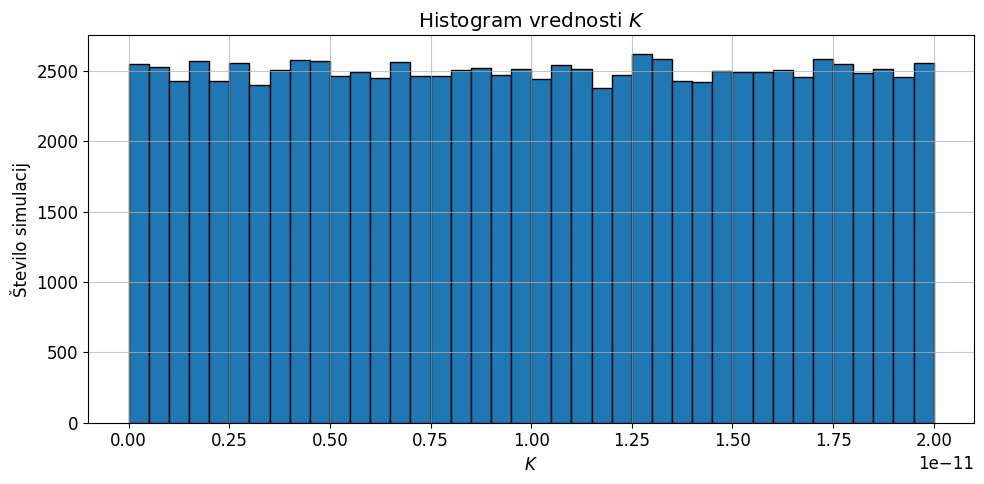

In [4]:
plt.figure(figsize=(10, 5))

plt.hist(Kvalues, bins=40, edgecolor='black')
plt.xlabel(r'$K$')
plt.ylabel('Število simulacij')
plt.title(r'Histogram vrednosti $K$')
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
print(np.min(Kvalues))
print(np.max(Kvalues))

1.937849993804974e-18
1.999990156099207e-11


- Povprečni profil intenzitete ter največja odstopanja

In [6]:
mean_I500_n0 = np.mean(I500_n0, axis=0)
distances = np.linalg.norm(I500_n0 - mean_I500_n0, axis=1)
n_top = 3
top_idx = np.argsort(distances)[-n_top:]
outliers_I = I500_n0[top_idx]
outliers_theta0 = theta0[top_idx]
outliers_Kvalues = Kvalues[top_idx]

C:\Users\tadej\AppData\Local\Temp\ipykernel_2736\1221122184.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


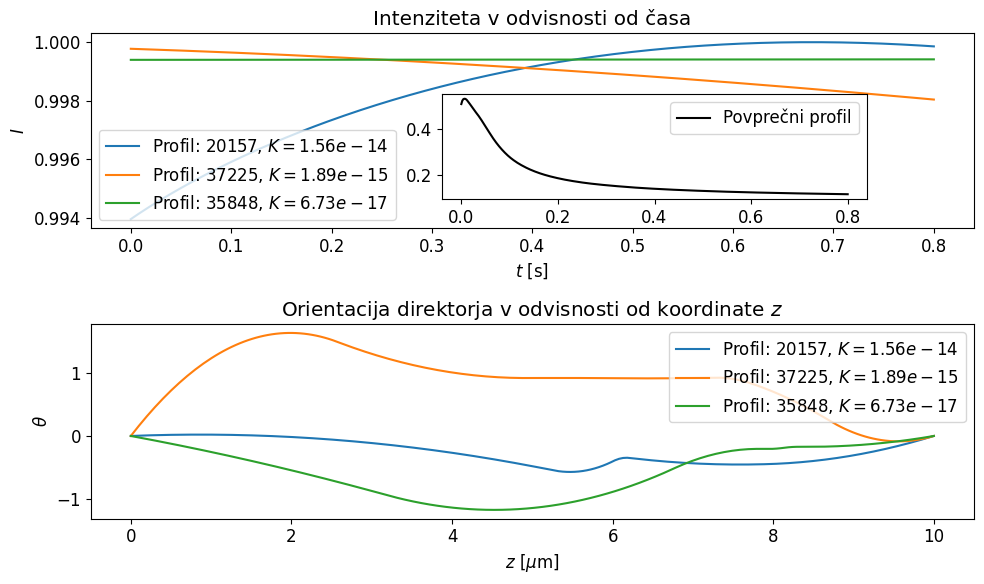

In [7]:
D = 10 * 1e-6 # Thicknes of layer in meters
n_z = np.shape(theta0[0])[0]
zs = np.linspace(0, D, n_z) * 1e6 # in um

T = 5 * 1e-6 * (240000 / 600)**2 # Time in seconds
n_t = np.shape(I500_n0[0])[0]
ts = np.linspace(0, T, n_t)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# axes[0].plot(ts, mean_I500_n0)

for i in range(len(outliers_I)):
    axes[0].plot(ts, outliers_I[i,:], label=rf"Profil: {top_idx[i]}, $K={outliers_Kvalues[i]:.2e}$")
    axes[1].plot(zs, outliers_theta0[i, :], label=rf"Profil: {top_idx[i]}, $K={outliers_Kvalues[i]:.2e}$")

ax_inset = fig.add_axes([0.45, 0.655, 0.425, 0.175])
ax_inset.plot(ts, mean_I500_n0, color='black', label='Povprečni profil')
ax_inset.legend()

axes[0].set_title('Intenziteta v odvisnosti od časa')
axes[0].set_xlabel(r'$t$ [s]')
axes[0].set_ylabel(r'$I$')
axes[0].legend(loc='lower left')

axes[1].set_title(r'Orientacija direktorja v odvisnosti od koordinate $z$')
axes[1].set_xlabel(r'$z$ [$\mu$m]')
axes[1].set_ylabel(r'$\theta$')
axes[1].legend(loc='upper right')

fig.tight_layout()

- Razllični šumi

C:\Users\tadej\AppData\Local\Temp\ipykernel_2736\1346921302.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='lower left')
C:\Users\tadej\AppData\Local\Temp\ipykernel_2736\1346921302.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='upper right')


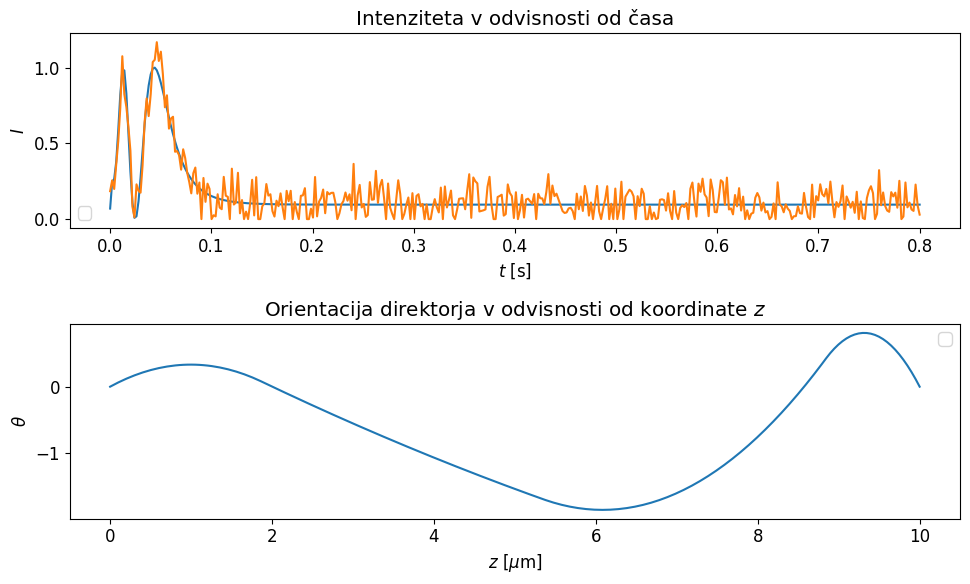

In [8]:
D = 10 * 1e-6 # Thicknes of layer in meters
n_z = np.shape(theta0[0])[0]
zs = np.linspace(0, D, n_z) * 1e6 # in um

T = 5 * 1e-6 * (240000 / 600)**2 # Time in seconds
n_t = np.shape(I500_n0[0])[0]
ts = np.linspace(0, T, n_t)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[1].plot(zs, theta0[200])
axes[0].plot(ts, I500_n0[200])
axes[0].plot(ts, I500_n100[200])

axes[0].set_title('Intenziteta v odvisnosti od časa')
axes[0].set_xlabel(r'$t$ [s]')
axes[0].set_ylabel(r'$I$')
axes[0].legend(loc='lower left')

axes[1].set_title(r'Orientacija direktorja v odvisnosti od koordinate $z$')
axes[1].set_xlabel(r'$z$ [$\mu$m]')
axes[1].set_ylabel(r'$\theta$')
axes[1].legend(loc='upper right')

fig.tight_layout()

- Razvoj profila v času

In [9]:
K_mean = np.mean(Kvalues)

idx_min = np.argmin(Kvalues)
idx_low = np.argmin(np.abs(Kvalues - K_mean/2))
idx_mean = np.argmin(np.abs(Kvalues - K_mean))
idx_high = np.argmin(np.abs(Kvalues - 3*K_mean/2))
idx_max = np.argmax(Kvalues)

th0_min = theta0[idx_min]
K_min = Kvalues[idx_min]
th0_low = theta0[idx_low]
K_low = Kvalues[idx_low]
th0_mean = theta0[idx_mean]
K_mean = Kvalues[idx_mean]
th0_high = theta0[idx_high]
K_high = Kvalues[idx_high]
th0_max = theta0[idx_max]
K_max = Kvalues[idx_max]

gamma1 = 0.098

th_min = theta_time_evolution(th0_min, K_min/gamma1)
th_low = theta_time_evolution(th0_low, K_low/gamma1)
th_mean = theta_time_evolution(th0_mean, K_mean/gamma1)
th_high = theta_time_evolution(th0_high, K_high/gamma1)
th_max = theta_time_evolution(th0_max, K_max/gamma1)

C:\Users\tadej\AppData\Local\Temp\ipykernel_2736\2538852963.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


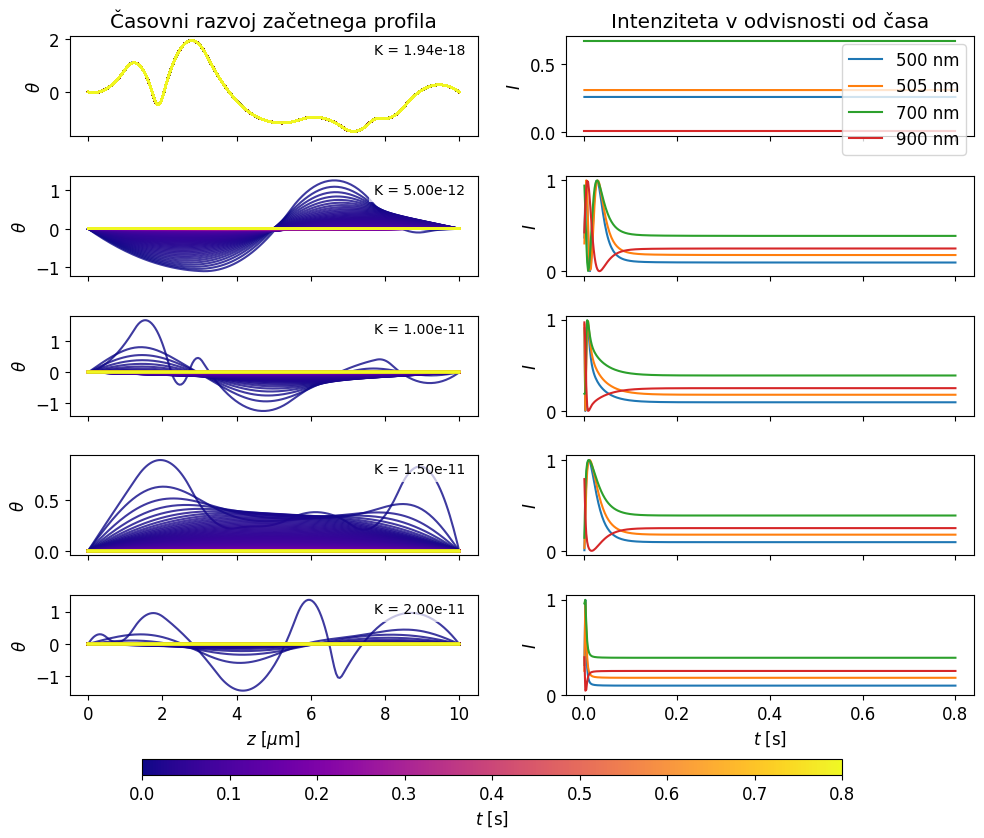

In [10]:
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(ts)))

fig, axes = plt.subplots(5, 2, figsize=(10, 8))

# nariši theta profile
for i, color in enumerate(colors):
    axes[0][0].plot(zs, th_min[i, :], color=color, alpha=0.8)
    axes[1][0].plot(zs, th_low[i, :], color=color, alpha=0.8)
    axes[2][0].plot(zs, th_mean[i, :], color=color, alpha=0.8)
    axes[3][0].plot(zs, th_high[i, :], color=color, alpha=0.8)
    axes[4][0].plot(zs, th_max[i, :], color=color, alpha=0.8)

Ks = [K_min, K_low, K_mean, K_high, K_max]
texts = [f"K = {K:.2e}" for K in Ks]

for i in range(5):
    axes[i][0].text(
        0.97, 0.93,               # pozicija (relativno v osi)
        texts[i],                 # besedilo
        transform=axes[i][0].transAxes,
        ha='right', va='top',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # opcijsko ozadje
    )

# nariši I profile
Is = [I500_n0, I505_n0, I700_n0, I900_n0]
labels = ['500 nm', '505 nm', '700 nm', '900 nm']
for i, I in enumerate(Is):
    axes[0][1].plot(ts, I[idx_min, :], label=labels[i])
    axes[1][1].plot(ts, I[idx_low, :], label=labels[i])
    axes[2][1].plot(ts, I[idx_mean, :], label=labels[i])
    axes[3][1].plot(ts, I[idx_high, :], label=labels[i])
    axes[4][1].plot(ts, I[idx_max, :], label=labels[i])

axes[0][1].legend()

# horizontalna barvna lestvica spodaj z add_axes
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=ts[0], vmax=ts[-1]))

# [x0, y0, širina, višina] v figure koordinatah
cbar_ax = fig.add_axes([0.15, 0.02, 0.70, 0.02])  # spodaj, čez cel fig
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'$t$ [s]')

# nastavitve osi in naslovi
axes[0][0].set_title('Časovni razvoj začetnega profila')
axes[0][0].set_ylabel(r'$\theta$')
axes[0][1].set_title('Intenziteta v odvisnosti od časa')
axes[0][1].set_ylabel(r'$I$')

for i in range(0, 5):
    axes[i][0].set_ylabel(r'$\theta$')
    axes[i][1].set_ylabel(r'$I$')
    
    # skrij x oznake za vse, razen spodnjega reda
    if i < 4:  # vrstice 0 do 3
        axes[i][0].tick_params(labelbottom=False)
        axes[i][1].tick_params(labelbottom=False)

axes[4][0].set_xlabel(r'$z$ [$\mu$m]')
axes[4][1].set_xlabel(r'$t$ [s]')

fig.tight_layout()
fig.subplots_adjust(bottom=0.12, hspace=0.4) # prilagodi spodnjo
plt.show()

In [11]:
# fig = plt.figure(figsize=(10, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Za vsak časovni korak narišemo profil kot 3D črto
# for i in range(n_t):
#     ax.plot(zs, ts[i] * np.ones(200), th[i, :], alpha=0.7)

# ax.set_xlabel('z')
# ax.set_ylabel('t')
# ax.set_zlabel('theta')

# ax.set_title(f'Time evolution of θ(z),  K = {K:.2e}')
# plt.tight_layout()
# plt.show()


# Konstrukcija nevronske mreže

- funkcije

In [3]:
def create_model(hidden_layers, size, activation):
    model = tf.keras.Sequential()

    # Input layer + prva skrita plast
    model.add(tf.keras.layers.Dense(size[0], activation=activation, input_shape=(400,)))

    # Preostale skrite plasti
    for i in range(1, hidden_layers):
        model.add(tf.keras.layers.Dense(size[i], activation=activation))

    # Izhodna plast
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # Compile
    model.compile(
        optimizer='adam',
        loss='mean_absolute_error',
        metrics=['mean_squared_error']
    )

    return model


def run_KFold(X, Y, hidden_layers, size, activation, save_path="saved_models"):
    
    # ustvari direktorij za shranjevanje modelov
    os.makedirs(save_path, exist_ok=True)

    kf = KFold(n_splits=5)

    scores_MAE = []
    scores_MSE = []
    histories = []
    best_model_paths = []

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    fold = 1
    for train_idx, test_idx in kf.split(X, Y):

        print(f"Training fold {fold}...")

        model = create_model(hidden_layers, size, activation)

        # pot za shranjevanje najboljšega modela
        model_path = os.path.join(save_path, f"best_model_fold_{fold}.keras")

        checkpoint = tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,   # shrani cel model (struktura + uteži)
            verbose=0
        )

        history = model.fit(
            X[train_idx], Y[train_idx],
            epochs=200,
            batch_size=100,
            verbose=0,
            validation_split=0.1,
            shuffle=True,
            callbacks=[early_stop, checkpoint]
        )

        histories.append(history)
        best_model_paths.append(model_path)

        # naložimo NAJBOLJŠI model iz datoteke
        best_model = tf.keras.models.load_model(model_path)

        # evaluacija najboljšega modela na testnem setu
        mae, mse = best_model.evaluate(X[test_idx], Y[test_idx], verbose=0)

        scores_MAE.append(mae)
        scores_MSE.append(mse)

        print(f" Fold {fold} → MAE = {mae:.4f}, MSE = {mse:.4f}")
        fold += 1

    # -----------------------------
    # Rezultati
    # -----------------------------
    print("\n============================")
    print("FINAL RESULTS OVER ALL FOLDS")
    print("============================")

    print(f"Average MAE: {np.mean(scores_MAE):.4f} ± {np.std(scores_MAE):.4f}")
    print(f"Average MSE: {np.mean(scores_MSE):.4f} ± {np.std(scores_MSE):.4f}")

    return scores_MAE, scores_MSE, histories, best_model_paths


## NEZAŠUMLJENI PODATKI

- Učenje samo na 500 nm (dona with 10 splits)

In [33]:
Kmax = 20e-12

X = I500_n0
Y = Kvalues/Kmax

n = X.shape[0]
nt = int(0.9*n)

X_train = X[:nt]
X_test = X[nt:]

Y_train = Y[:nt]
Y_test = Y[nt:]

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(90000, 400)
(10000, 400)
(90000,)
(10000,)


In [26]:
hidden_layers = 2
size = [200, 100]
activation = 'sigmoid'
save_path = f"saved_HL-{hidden_layers}_act-{activation}"

scores_MAE_sigmoid, scores_MSE_sigmoid, histories_sigmoid, best_sigmoid = run_KFold(X_train, Y_train, hidden_layers, size, activation, save_path)

Training fold 1...


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Fold 1 → MAE = 0.0376, MSE = 0.0091
Training fold 2...
 Fold 2 → MAE = 0.0690, MSE = 0.0164
Training fold 3...
 Fold 3 → MAE = 0.0680, MSE = 0.0161
Training fold 4...
 Fold 4 → MAE = 0.0658, MSE = 0.0152
Training fold 5...
 Fold 5 → MAE = 0.0671, MSE = 0.0162
Training fold 6...
 Fold 6 → MAE = 0.0691, MSE = 0.0163
Training fold 7...
 Fold 7 → MAE = 0.0680, MSE = 0.0157
Training fold 8...
 Fold 8 → MAE = 0.0710, MSE = 0.0171
Training fold 9...
 Fold 9 → MAE = 0.0718, MSE = 0.0168
Training fold 10...
 Fold 10 → MAE = 0.0727, MSE = 0.0164

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0660 ± 0.0097
Average MSE: 0.0155 ± 0.0022


In [27]:
hidden_layers = 2
size = [200, 100]
activation = 'tanh'
save_path = f"saved_HL-{hidden_layers}_act-{activation}"

scores_MAE_tanh, scores_MSE_tanh, histories_tanh, best_tanh = run_KFold(X_train, Y_train, hidden_layers, size, activation, save_path)

Training fold 1...


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Fold 1 → MAE = 0.0331, MSE = 0.0069
Training fold 2...
 Fold 2 → MAE = 0.0494, MSE = 0.0120
Training fold 3...
 Fold 3 → MAE = 0.0476, MSE = 0.0116
Training fold 4...
 Fold 4 → MAE = 0.0543, MSE = 0.0122
Training fold 5...
 Fold 5 → MAE = 0.0527, MSE = 0.0128
Training fold 6...
 Fold 6 → MAE = 0.0514, MSE = 0.0133
Training fold 7...
 Fold 7 → MAE = 0.0546, MSE = 0.0126
Training fold 8...
 Fold 8 → MAE = 0.0525, MSE = 0.0122
Training fold 9...
 Fold 9 → MAE = 0.0504, MSE = 0.0121
Training fold 10...
 Fold 10 → MAE = 0.0495, MSE = 0.0124

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0495 ± 0.0059
Average MSE: 0.0118 ± 0.0017


In [28]:
hidden_layers = 2
size = [200, 100]
activation = 'relu'
save_path = f"saved_HL-{hidden_layers}_act-{activation}"

scores_MAE_relu, scores_MSE_relu, histories_relu, best_relu = run_KFold(X_train, Y_train, hidden_layers, size, activation, save_path)

Training fold 1...
 Fold 1 → MAE = 0.0278, MSE = 0.0061
Training fold 2...
 Fold 2 → MAE = 0.0474, MSE = 0.0093
Training fold 3...
 Fold 3 → MAE = 0.0478, MSE = 0.0092
Training fold 4...
 Fold 4 → MAE = 0.0464, MSE = 0.0100
Training fold 5...
 Fold 5 → MAE = 0.0493, MSE = 0.0111
Training fold 6...
 Fold 6 → MAE = 0.0461, MSE = 0.0110
Training fold 7...
 Fold 7 → MAE = 0.0428, MSE = 0.0100
Training fold 8...
 Fold 8 → MAE = 0.0483, MSE = 0.0098
Training fold 9...
 Fold 9 → MAE = 0.0467, MSE = 0.0105
Training fold 10...
 Fold 10 → MAE = 0.0512, MSE = 0.0109

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0454 ± 0.0062
Average MSE: 0.0098 ± 0.0014


In [29]:
hidden_layers = 2
size = [200, 100]
activation = 'linear'
save_path = f"saved_HL-{hidden_layers}_act-{activation}"

scores_MAE_linear, scores_MSE_linear, histories_linear, best_linear = run_KFold(X_train, Y_train, hidden_layers, size, activation, save_path)

Training fold 1...
 Fold 1 → MAE = 0.1586, MSE = 0.0438
Training fold 2...
 Fold 2 → MAE = 0.1552, MSE = 0.0426
Training fold 3...
 Fold 3 → MAE = 0.1568, MSE = 0.0441
Training fold 4...
 Fold 4 → MAE = 0.1575, MSE = 0.0434
Training fold 5...
 Fold 5 → MAE = 0.1575, MSE = 0.0433
Training fold 6...
 Fold 6 → MAE = 0.1597, MSE = 0.0446
Training fold 7...
 Fold 7 → MAE = 0.1572, MSE = 0.0437
Training fold 8...
 Fold 8 → MAE = 0.1594, MSE = 0.0445
Training fold 9...
 Fold 9 → MAE = 0.1590, MSE = 0.0442
Training fold 10...
 Fold 10 → MAE = 0.1570, MSE = 0.0430

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1578 ± 0.0013
Average MSE: 0.0437 ± 0.0006


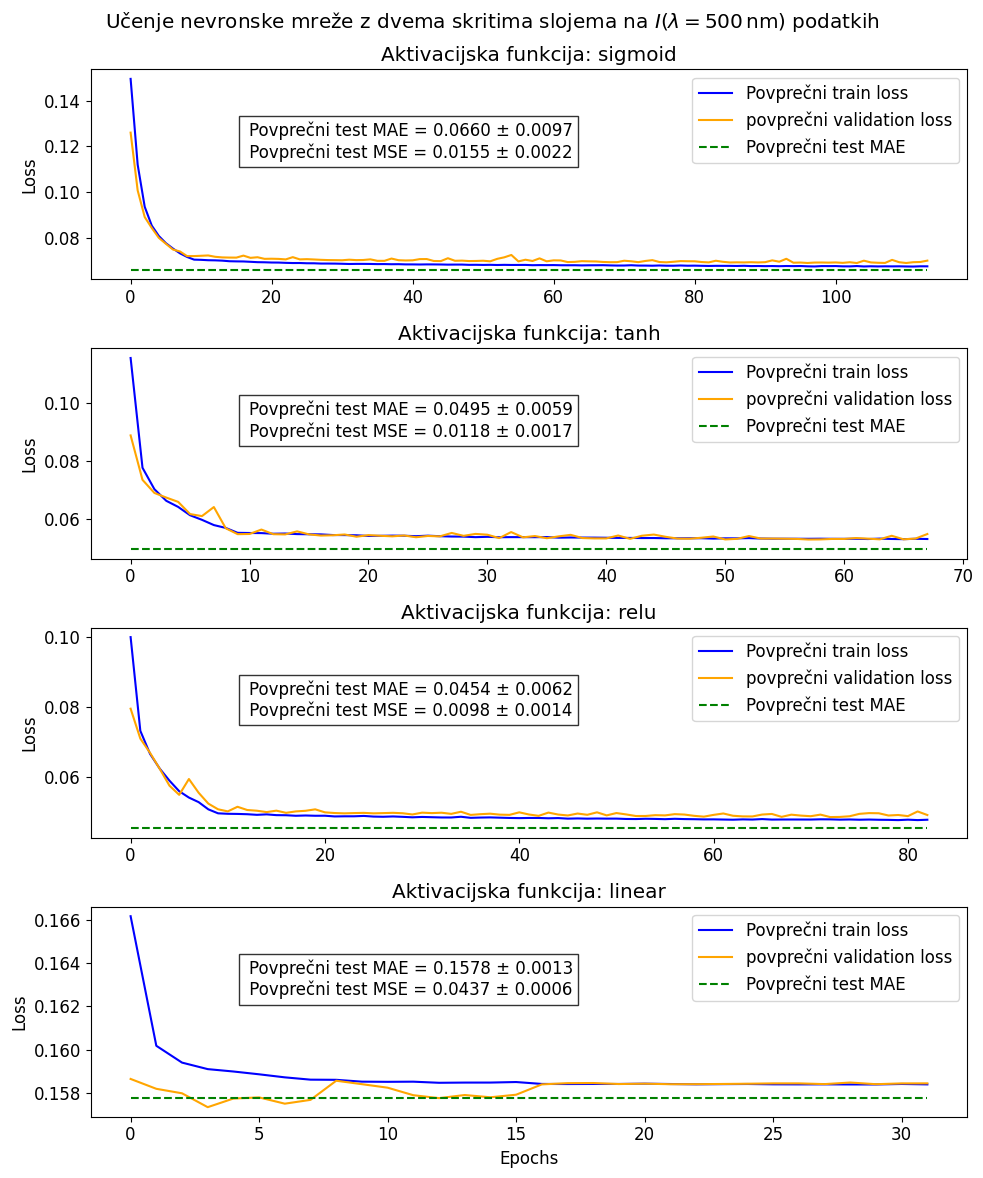

In [ ]:
activations = ['sigmoid', 'tanh', 'relu', 'linear']
histories_all = [histories_sigmoid, histories_tanh, histories_relu, histories_linear]
scores_all = [scores_MAE_sigmoid, scores_MAE_tanh, scores_MAE_relu, scores_MAE_linear]

MAEs = ["0.0660 ± 0.0097", "0.0495 ± 0.0059", "0.0454 ± 0.0062", "0.1578 ± 0.0013"]
MSEs = ["0.0155 ± 0.0022", "0.0118 ± 0.0017", "0.0098 ± 0.0014", "0.0437 ± 0.0006"]

fig, axes = plt.subplots(4, 1, figsize=(10, 12))
fig.suptitle(r'Učenje nevronske mreže z dvema skritima slojema na $I(\lambda = 500 \, \text{nm})$ podatkih')
for i, (act, histories, scores) in enumerate(zip(activations, histories_all, scores_all)):
    
    # združi train in val loss vseh fold-ov
    max_epochs = max([len(h.history['loss']) for h in histories])
    train_losses = np.zeros((len(histories), max_epochs))
    val_losses = np.zeros((len(histories), max_epochs))
    
    for j, h in enumerate(histories):
        le = len(h.history['loss'])
        train_losses[j, :le] = h.history['loss']
        val_losses[j, :le] = h.history['val_loss']
        if le < max_epochs:
            # napolni preostanek z zadnjo vrednostjo
            train_losses[j, le:] = h.history['loss'][-1]
            val_losses[j, le:] = h.history['val_loss'][-1]

    # povprečje čez fold-e
    mean_train = np.mean(train_losses, axis=0)
    mean_val = np.mean(val_losses, axis=0)
    
    axes[i].plot(mean_train, label='Povprečni train loss', color='blue')
    axes[i].plot(mean_val, label='povprečni validation loss', color='orange')
    
    # povprečen test MAE čez fold-e
    axes[i].hlines(np.mean(scores), 0, max_epochs-1, colors='green', linestyles='dashed', label='Povprečni test MAE')
    
    # dodaj tekst z MAE in MSE
    text_str = f"Povprečni test MAE = {MAEs[i]}\n Povprečni test MSE = {MSEs[i]}"
    axes[i].text(0.55, 0.75, text_str,
                 transform=axes[i].transAxes,  # koordinate od 0 do 1 v subplotu
                 verticalalignment='top',
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].set_title(f'Aktivacijska funkcija: {act}')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

axes[-1].set_xlabel('Epochs')
plt.tight_layout()
plt.show()

- Učenje na vseh podatkih

In [ ]:
root = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF3\\data\\TestNTrain\\"
X = np.load(root + "X.npy")
X_test  = np.load(root + "X_test.npy")
Y = np.load(root + "Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "Y_test.npy")

- Dimenzija mreže

In [40]:
hidden_layers = 1
size = [200]
activation = 'relu'
save_path = f"models\\saved_HL-{hidden_layers}_act-{activation}"

MAE_relu_all_1, MSE_relu_all_1, histories_relu_all_1, best_relu_all_1 = run_KFold(X, Y, hidden_layers, size, activation, save_path)

Training fold 1...
 Fold 1 → MAE = 25016385536.0000, MSE = 834984822363046019072.0000
Training fold 2...
 Fold 2 → MAE = 24997314560.0000, MSE = 833624101956882530304.0000
Training fold 3...
 Fold 3 → MAE = 25030748160.0000, MSE = 834502655727940665344.0000
Training fold 4...
 Fold 4 → MAE = 24991139840.0000, MSE = 833017875225791954944.0000
Training fold 5...


KeyboardInterrupt: 

In [ ]:
hidden_layers = 2
size = [200, 100]
activation = 'relu'
save_path = f"models\\saved_HL-{hidden_layers}_act-{activation}"

MAE_relu_all_2, MSE_relu_all_2, histories_relu_all_2, best_relu_all_2 = run_KFold(X, Y, hidden_layers, size, activation, save_path)

Training fold 1...
 Fold 1 → MAE = 0.0447, MSE = 0.0095
Training fold 2...
 Fold 2 → MAE = 0.0514, MSE = 0.0112
Training fold 3...
 Fold 3 → MAE = 0.0529, MSE = 0.0115
Training fold 4...
 Fold 4 → MAE = 0.0512, MSE = 0.0112
Training fold 5...
 Fold 5 → MAE = 0.0561, MSE = 0.0122

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0513 ± 0.0037
Average MSE: 0.0111 ± 0.0009


In [ ]:
hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path = f"models\\saved_HL-{hidden_layers}_act-{activation}"

MAE_relu_all_3, MSE_relu_all_3, histories_relu_all_3, best_relu_all_3 = run_KFold(X, Y, hidden_layers, size, activation, save_path)

Training fold 1...
 Fold 1 → MAE = 0.0278, MSE = 0.0056
Training fold 2...
 Fold 2 → MAE = 0.0450, MSE = 0.0104
Training fold 3...
 Fold 3 → MAE = 0.0457, MSE = 0.0100
Training fold 4...
 Fold 4 → MAE = 0.0472, MSE = 0.0099
Training fold 5...
 Fold 5 → MAE = 0.0451, MSE = 0.0091

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0421 ± 0.0072
Average MSE: 0.0090 ± 0.0018


In [ ]:
hidden_layers = 4
size = [200, 100, 50, 10]
activation = 'relu'
save_path = f"models\\saved_HL-{hidden_layers}_act-{activation}"

MAE_relu_all_4, MSE_relu_all_4, histories_relu_all_4, best_relu_all_4 = run_KFold(X, Y, hidden_layers, size, activation, save_path)

Training fold 1...
 Fold 1 → MAE = 0.0299, MSE = 0.0059
Training fold 2...
 Fold 2 → MAE = 0.0462, MSE = 0.0097
Training fold 3...
 Fold 3 → MAE = 0.0457, MSE = 0.0105
Training fold 4...
 Fold 4 → MAE = 0.0444, MSE = 0.0097
Training fold 5...
 Fold 5 → MAE = 0.0519, MSE = 0.0106

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0436 ± 0.0073
Average MSE: 0.0093 ± 0.0018


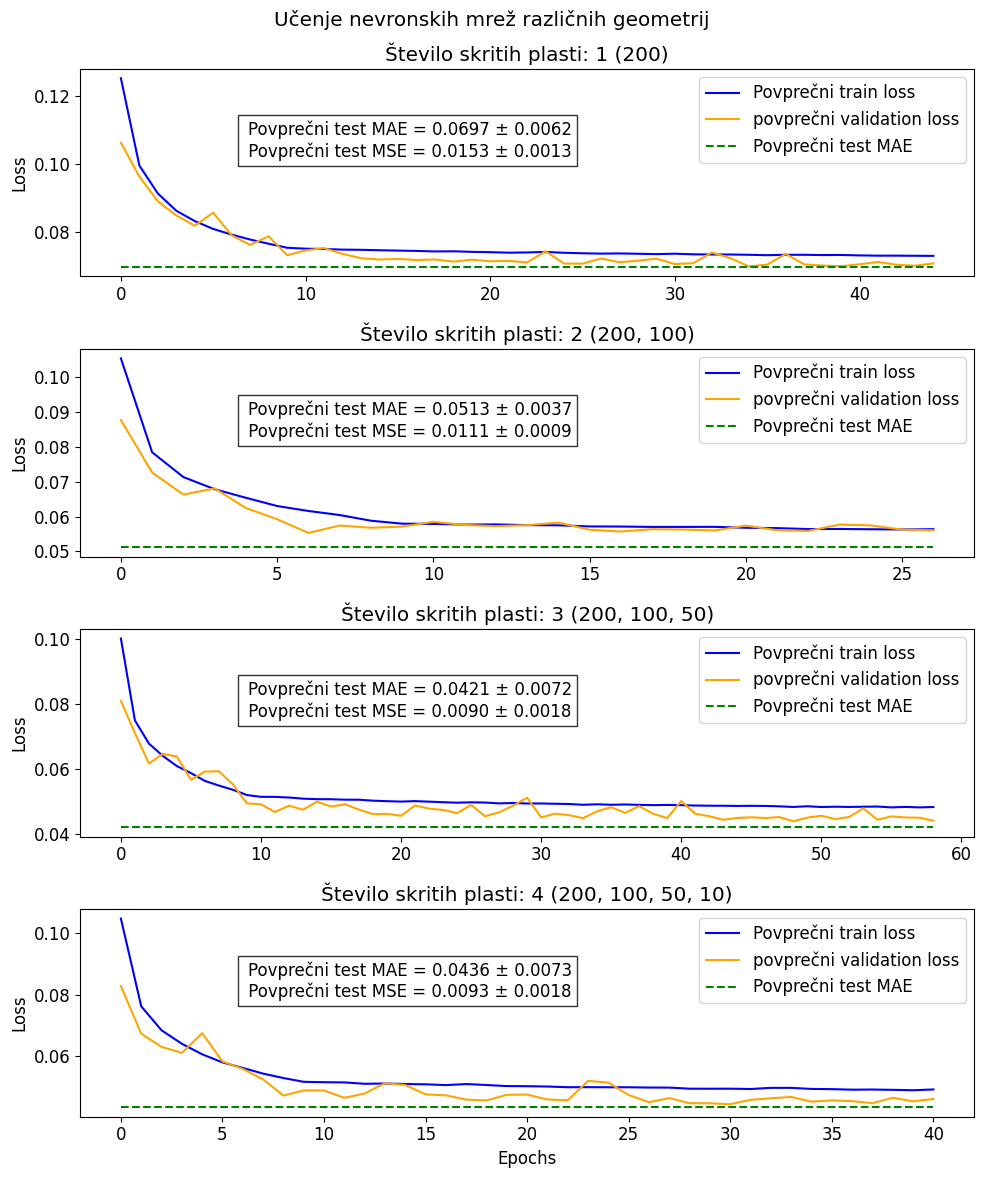

In [ ]:
layers = ['1 (200)', '2 (200, 100)', '3 (200, 100, 50)', '4 (200, 100, 50, 10)']
histories_all = [histories_relu_all_1, histories_relu_all_2, histories_relu_all_3, histories_relu_all_4] #RELU not relu # Fail
scores_all = [MAE_relu_all_1, MAE_relu_all_2, MAE_relu_all_3, MAE_relu_all_4]

MAEs = ["0.0697 ± 0.0062", "0.0513 ± 0.0037", "0.0421 ± 0.0072", "0.0436 ± 0.0073"]
MSEs = ["0.0153 ± 0.0013", "0.0111 ± 0.0009", "0.0090 ± 0.0018", "0.0093 ± 0.0018"]

fig, axes = plt.subplots(4, 1, figsize=(10, 12))
fig.suptitle(r'Učenje nevronskih mrež različnih geometrij')
for i, (num, histories, scores) in enumerate(zip(layers, histories_all, scores_all)):
    
    # združi train in val loss vseh fold-ov
    max_epochs = max([len(h.history['loss']) for h in histories])
    train_losses = np.zeros((len(histories), max_epochs))
    val_losses = np.zeros((len(histories), max_epochs))
    
    for j, h in enumerate(histories):
        le = len(h.history['loss'])
        train_losses[j, :le] = h.history['loss']
        val_losses[j, :le] = h.history['val_loss']
        if le < max_epochs:
            # napolni preostanek z zadnjo vrednostjo
            train_losses[j, le:] = h.history['loss'][-1]
            val_losses[j, le:] = h.history['val_loss'][-1]

    # povprečje čez fold-e
    mean_train = np.mean(train_losses, axis=0)
    mean_val = np.mean(val_losses, axis=0)
    
    axes[i].plot(mean_train, label='Povprečni train loss', color='blue')
    axes[i].plot(mean_val, label='povprečni validation loss', color='orange')
    
    # povprečen test MAE čez fold-e
    axes[i].hlines(np.mean(scores), 0, max_epochs-1, colors='green', linestyles='dashed', label='Povprečni test MAE')
    
    # dodaj tekst z MAE in MSE
    text_str = f"Povprečni test MAE = {MAEs[i]}\n Povprečni test MSE = {MSEs[i]}"
    axes[i].text(0.55, 0.75, text_str,
                 transform=axes[i].transAxes,  # koordinate od 0 do 1 v subplotu
                 verticalalignment='top',
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].set_title(f'Število skritih plasti: {num}')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

axes[-1].set_xlabel('Epochs')
plt.tight_layout()
plt.show()


- Napovedi najboljše mreže

In [ ]:
model = tf.keras.models.load_model("models\\saved_HL-3_act-relu\\best_model_fold_1.keras")
Y_pred = model.predict(X_test).flatten()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 705us/step


In [ ]:
tol = 0.1  # 5%

lower = (1 - tol) * Y_test
upper = (1 + tol) * Y_test

inside = (Y_pred >= lower) & (Y_pred <= upper)
fraction_inside = np.mean(inside)

print("Delež točk znotraj ±5% diagonale:", fraction_inside)

Delež točk znotraj ±5% diagonale: 0.81875


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


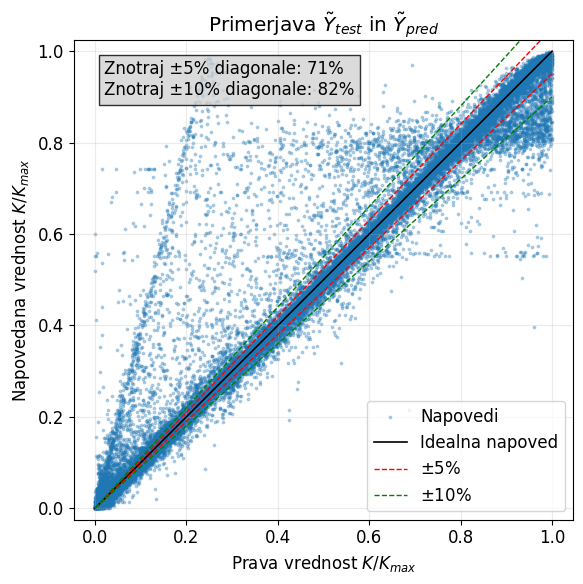

In [ ]:
plt.figure(figsize=(6, 6))

# Scatter
plt.scatter(Y_test, Y_pred, alpha=0.3, s=3, label="Napovedi")

# Glavna diagonala
min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
x_line = np.linspace(min_val, max_val, 500)

plt.plot(x_line, x_line, color="black", linewidth=1.2, label="Idealna napoved")

# ±5 % meje
plt.plot(x_line, 1.05 * x_line, color="red", linestyle="--", linewidth=1, label=r"$\pm 5$%")
plt.plot(x_line, 0.95 * x_line, color="red", linestyle="--", linewidth=1)
plt.plot(x_line, 1.1 * x_line, color="green", linestyle="--", linewidth=1, label=r"$\pm 10$%")
plt.plot(x_line, 0.9 * x_line, color="green", linestyle="--", linewidth=1)

plt.text(0.02, 0.98, r"Znotraj ±5% diagonale: 71%" + "\n" + r"Znotraj ±10% diagonale: 82%",
             verticalalignment='top',
             horizontalalignment='left',
             bbox=dict(facecolor='lightgray', alpha=0.8))

# Lepša oblika
plt.xlabel(r"Prava vrednost $K/K_{max}$")
plt.ylabel(r"Napovedana vrednost $K/K_{max}$")
plt.title(r"Primerjava $\tilde{Y}_{test}$ in $\tilde{Y}_{pred}$")
plt.legend()
plt.grid(alpha=0.25)
plt.axis("equal")  # ohrani razmerje osi zaradi diagonale
plt.xlim((-0.025, 1.025))
plt.ylim((-0.025, 1.025))

plt.tight_layout()
plt.show()


## ZAŠUMLJENI PODATKI

- shranjeni podatki v TestNTrain2

In [ ]:
# # združi vse I*_n100
# X100 = np.concatenate([I500_n100, I505_n100, I700_n100, I900_n100], axis=0)
# X = np.concatenate([I500_n0, I505_n0, I700_n0, I900_n0], axis=0)
# Y = np.concatenate([Kvalues, Kvalues, Kvalues, Kvalues], axis=0)/Kmax

# # shuffle indeksov
# indices = np.arange(X100.shape[0])
# np.random.shuffle(indices)

# X100 = X100[indices]
# X = X[indices]
# Y = Y[indices]

# # Razdelitev na train/test
# n = X.shape[0]
# nt = int(0.9 * n)

# X100_train = X100[:nt]
# X100_test  = X100[nt:]
# X_train = X[:nt]
# X_test  = X[nt:]

# Y_train = Y[:nt]
# Y_test  = Y[nt:]

# print(X100_train.shape, X100_test.shape, Y_train.shape, Y_test.shape)

# # Shrani podatke
# np.save("X100.npy", X100_train)
# np.save("X100_test.npy", X100_test)
# np.save("X.npy", X_train)
# np.save("X_test.npy", X_test)
# np.save("Y.npy", Y_train)
# np.save("Y_test.npy", Y_test)

(360000, 400) (40000, 400) (360000,) (40000,)


In [4]:
root = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF3\\data\\TestNTrain2\\"
X100 = np.load(root + "X100.npy")
X100_test  = np.load(root + "X100_test.npy")
X = np.load(root + "X.npy")
X_test  = np.load(root + "X_test.npy")
Y = np.load(root + "Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "Y_test.npy")

In [5]:
hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path = f"models2\\model100"

MAE100_relu, MSE100_relu, histories100_relu, best100_relu = run_KFold(X100, Y, hidden_layers, size, activation, save_path)

Training fold 1...


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Fold 1 → MAE = 0.0975, MSE = 0.0253
Training fold 2...
 Fold 2 → MAE = 0.0984, MSE = 0.0247
Training fold 3...
 Fold 3 → MAE = 0.0993, MSE = 0.0257
Training fold 4...
 Fold 4 → MAE = 0.0985, MSE = 0.0252
Training fold 5...
 Fold 5 → MAE = 0.0994, MSE = 0.0251

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0986 ± 0.0007
Average MSE: 0.0252 ± 0.0003


In [6]:
hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path = f"models2\\model0"

MAE_relu, MSE_relu, histories_relu, best_relu = run_KFold(X, Y, hidden_layers, size, activation, save_path)

Training fold 1...
 Fold 1 → MAE = 0.0366, MSE = 0.0075
Training fold 2...
 Fold 2 → MAE = 0.0431, MSE = 0.0089
Training fold 3...
 Fold 3 → MAE = 0.0457, MSE = 0.0094
Training fold 4...
 Fold 4 → MAE = 0.0472, MSE = 0.0100
Training fold 5...
 Fold 5 → MAE = 0.0459, MSE = 0.0093

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.0437 ± 0.0038
Average MSE: 0.0090 ± 0.0008


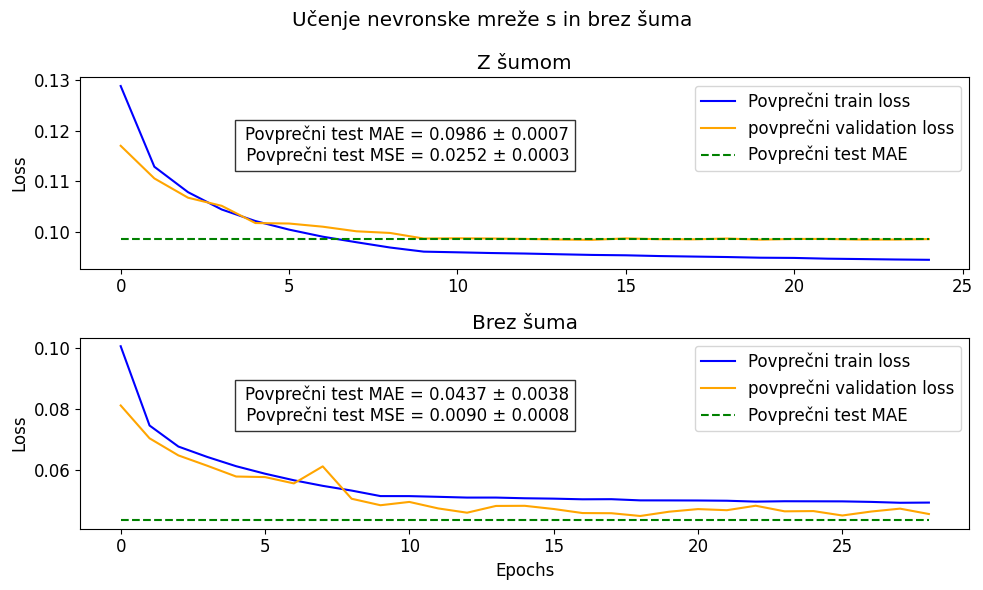

In [10]:
noise = ['Z šumom', 'Brez šuma']
histories_all = [histories100_relu, histories_relu]
scores_all = [MAE100_relu, MAE_relu]

MAEs = ["0.0986 ± 0.0007", "0.0437 ± 0.0038"]
MSEs = ["0.0252 ± 0.0003", "0.0090 ± 0.0008"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
fig.suptitle(r'Učenje nevronske mreže s in brez šuma')
for i, (title, histories, scores) in enumerate(zip(noise, histories_all, scores_all)):
    
    # združi train in val loss vseh fold-ov
    max_epochs = max([len(h.history['loss']) for h in histories])
    train_losses = np.zeros((len(histories), max_epochs))
    val_losses = np.zeros((len(histories), max_epochs))
    
    for j, h in enumerate(histories):
        le = len(h.history['loss'])
        train_losses[j, :le] = h.history['loss']
        val_losses[j, :le] = h.history['val_loss']
        if le < max_epochs:
            # napolni preostanek z zadnjo vrednostjo
            train_losses[j, le:] = h.history['loss'][-1]
            val_losses[j, le:] = h.history['val_loss'][-1]

    # povprečje čez fold-e
    mean_train = np.mean(train_losses, axis=0)
    mean_val = np.mean(val_losses, axis=0)
    
    axes[i].plot(mean_train, label='Povprečni train loss', color='blue')
    axes[i].plot(mean_val, label='povprečni validation loss', color='orange')
    
    # povprečen test MAE čez fold-e
    axes[i].hlines(np.mean(scores), 0, max_epochs-1, colors='green', linestyles='dashed', label='Povprečni test MAE')
    
    # dodaj tekst z MAE in MSE
    text_str = f"Povprečni test MAE = {MAEs[i]}\n Povprečni test MSE = {MSEs[i]}"
    axes[i].text(0.55, 0.75, text_str,
                 transform=axes[i].transAxes,  # koordinate od 0 do 1 v subplotu
                 verticalalignment='top',
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].set_title(f'{title}')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

axes[-1].set_xlabel('Epochs')
plt.tight_layout()
plt.show()


- Napovedi najboljše mreže naučene brez šuma ter s šumom

In [11]:
model100 = tf.keras.models.load_model("models2\\model100\\best_model_fold_1.keras")
model0 = tf.keras.models.load_model("models2\\model0\\best_model_fold_1.keras")

Y_pred_0 = model0.predict(X_test).flatten()
Y100_pred_0 = model0.predict(X100_test).flatten()
Y_pred_100 = model100.predict(X_test).flatten()
Y100_pred_100 = model100.predict(X100_test).flatten()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step


In [ ]:
tol = 0.05  # 5%

lower = (1 - tol) * Y_test
upper = (1 + tol) * Y_test

inside = (Y_pred >= lower) & (Y_pred <= upper)
fraction_inside = np.mean(inside)

print("Delež točk znotraj ±5% diagonale:", fraction_inside)

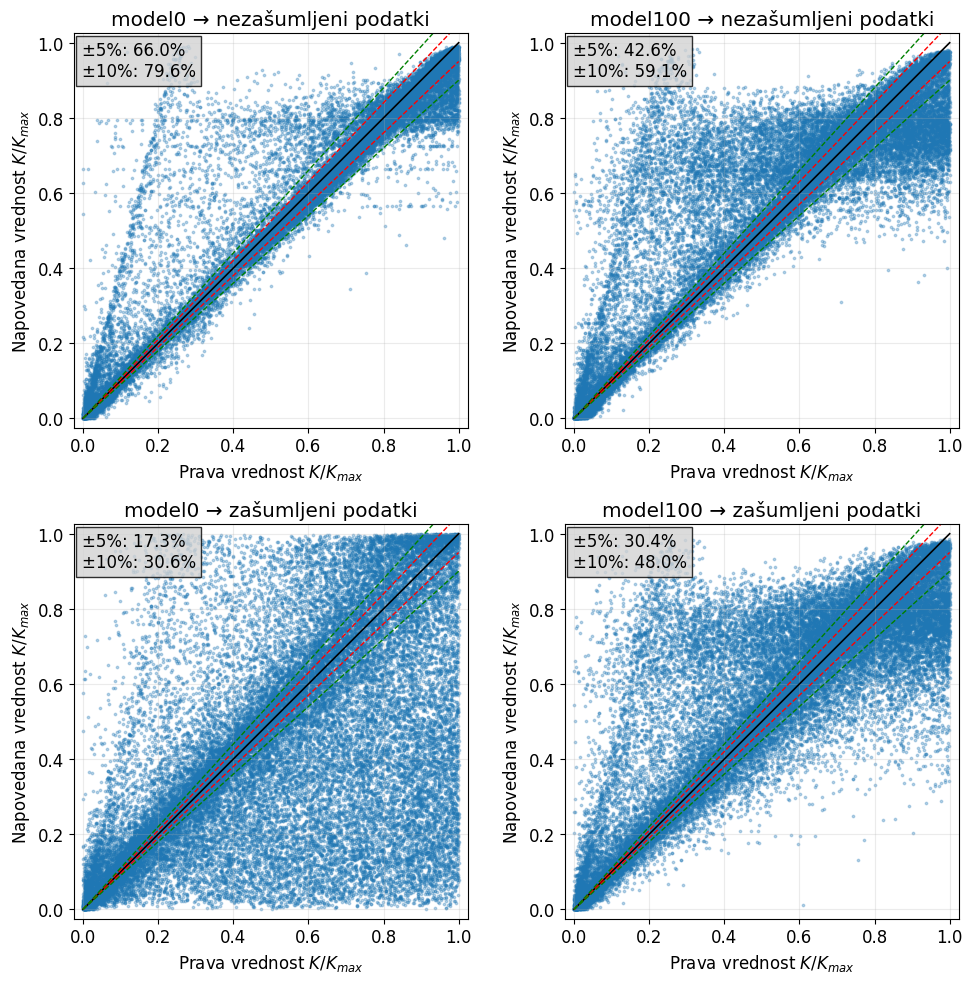

In [14]:
def plot_pred(ax, Y_true, Y_pred, title=""):
    # Scatter
    ax.scatter(Y_true, Y_pred, alpha=0.3, s=3, label="Napovedi")

    # diagonala
    min_val = min(Y_true.min(), Y_pred.min())
    max_val = max(Y_true.max(), Y_pred.max())
    x_line = np.linspace(min_val, max_val, 500)
    ax.plot(x_line, x_line, color="black", linewidth=1.2, label="Idealna napoved")

    # ±5 %, ±10 %
    ax.plot(x_line, 1.05 * x_line, color="red", linestyle="--", linewidth=1, label=r"$\pm 5$%")
    ax.plot(x_line, 0.95 * x_line, color="red", linestyle="--", linewidth=1)
    ax.plot(x_line, 1.10 * x_line, color="green", linestyle="--", linewidth=1, label=r"$\pm 10$%")
    ax.plot(x_line, 0.90 * x_line, color="green", linestyle="--", linewidth=1)

    # izračun deležev
    inside5 = ((Y_pred >= 0.95*Y_true) & (Y_pred <= 1.05*Y_true)).mean()
    inside10 = ((Y_pred >= 0.90*Y_true) & (Y_pred <= 1.10*Y_true)).mean()

    ax.text(
        0.02, 0.98,
        rf"±5%: {inside5*100:.1f}%"
        "\n" +
        rf"±10%: {inside10*100:.1f}%",
        verticalalignment='top',
        horizontalalignment='left',
        transform=ax.transAxes,
        bbox=dict(facecolor='lightgray', alpha=0.8)
    )

    # lepša oblika
    ax.set_xlabel(r"Prava vrednost $K/K_{max}$")
    ax.set_ylabel(r"Napovedana vrednost $K/K_{max}$")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.set_xlim((-0.025, 1.025))
    ax.set_ylim((-0.025, 1.025))
    ax.set_aspect('equal', 'box')


# ----- FIGURA 2×2 -----

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

plot_pred(axes[0, 0], Y_test, Y_pred_0,
          "model0 → nezašumljeni podatki")

plot_pred(axes[0, 1], Y_test, Y_pred_100,
          "model100 → nezašumljeni podatki")

plot_pred(axes[1, 0], Y_test, Y100_pred_0,
          "model0 → zašumljeni podatki")

plot_pred(axes[1, 1], Y_test, Y100_pred_100,
          "model100 → zašumljeni podatki")

plt.tight_layout()
plt.show()